# 05 — Profit Demonstration (Practical Investor View)

This notebook shows whether following the system's net strategy returns would have grown capital versus passive spread exposure.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PROCESSED = ROOT / 'data' / 'processed'

ret_path = PROCESSED / 'ml_backtest_monthly_returns.csv'
dec_path = PROCESSED / 'ml_signals_decisions.csv'

missing = [p for p in [ret_path, dec_path] if not p.exists()]
print(f'Missing artifacts: {len(missing)}')
for p in missing:
    print(' -', p)
if missing:
    raise SystemExit('Run 00_cache_and_run_control.ipynb in full mode first.')

Missing artifacts: 0


## Practical Value with Statistical Discipline

This notebook demonstrates capital-path intuition, but headline interpretation must remain subordinate to inference and stability evidence from notebooks `03` and `04`.

### Claim Policy
- **Supported by statistical evidence**
- **Economically promising but not statistically strong**
- **Exploratory / not used for headline claims**

In [2]:
ret = pd.read_csv(ret_path, parse_dates=['date']).set_index('date').sort_index()
dec = pd.read_csv(dec_path, parse_dates=['date']).set_index('date').sort_index()

df = ret.join(dec[['trade_enabled', 'reason_code']], how='left')
df['trade_enabled'] = pd.to_numeric(df['trade_enabled'], errors='coerce').fillna(0).astype(int)
df['reason_code'] = df['reason_code'].fillna('n/a')

initial_capital = 100.0
df['capital_system_net'] = initial_capital * (1.0 + df['strategy_net_ret']).cumprod()
df['capital_passive_net'] = initial_capital * (1.0 + df['passive_net_ret']).cumprod()
df['profit_delta'] = df['capital_system_net'] - df['capital_passive_net']

display(df.tail(12))

,spread_ret,ml_signal_raw,signal,turnover,strategy_gross_ret,strategy_net_ret,strategy_cost,passive_signal,passive_turnover,passive_gross_ret,passive_net_ret,passive_cost,trade_enabled,reason_code,capital_system_net,capital_passive_net,profit_delta
date,,,,,,,,,,,,,,,,,
2025-01-31,-0.013553,-1.0,1.0,0.0,-0.013553,-0.013553,0.0000,1.0,0.0,-0.013553,-0.013553,0.0,0,signal_disagreement,102.968909,92.956783,10.012126
2025-02-28,0.010953,-1.0,-1.0,2.0,-0.010953,-0.011953,0.0010,1.0,0.0,0.010953,0.010953,0.0,1,confirmed,101.738122,93.974938,7.763183
2025-03-31,0.002877,-1.0,-1.0,0.0,-0.002877,-0.002877,0.0000,1.0,0.0,0.002877,0.002877,0.0,1,confirmed,101.445421,94.245304,7.200117
2025-04-30,-0.004886,-1.0,-1.0,0.0,0.004886,0.004886,0.0000,1.0,0.0,-0.004886,-0.004886,0.0,1,confirmed,101.941083,93.784822,8.156262
2025-05-31,0.001669,-1.0,-1.0,0.0,-0.001669,-0.001669,0.0000,1.0,0.0,0.001669,0.001669,0.0,1,confirmed,101.770944,93.941349,7.829595
2025-06-30,0.008157,0.0,-1.0,0.0,-0.008157,-0.008157,0.0000,1.0,0.0,0.008157,0.008157,0.0,0,neutral_signal,100.940798,94.707628,6.233170
2025-07-31,0.006775,0.0,0.0,1.0,0.000000,-0.000500,0.0005,1.0,0.0,0.006775,0.006775,0.0,0,neutral_signal,100.890328,95.349272,5.541055
2025-08-31,0.002835,0.0,0.0,0.0,0.000000,0.000000,0.0000,1.0,0.0,0.002835,0.002835,0.0,0,neutral_signal,100.890328,95.619588,5.270740
2025-09-30,-0.010074,-1.0,0.0,0.0,-0.000000,-0.000000,0.0000,1.0,0.0,-0.010074,-0.010074,0.0,1,confirmed,100.890328,94.656316,6.234012


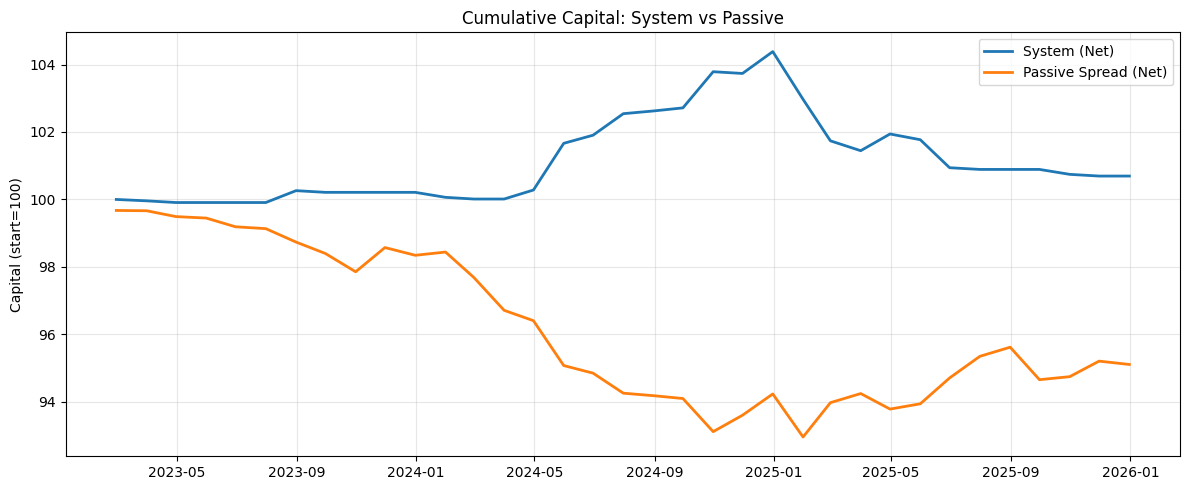

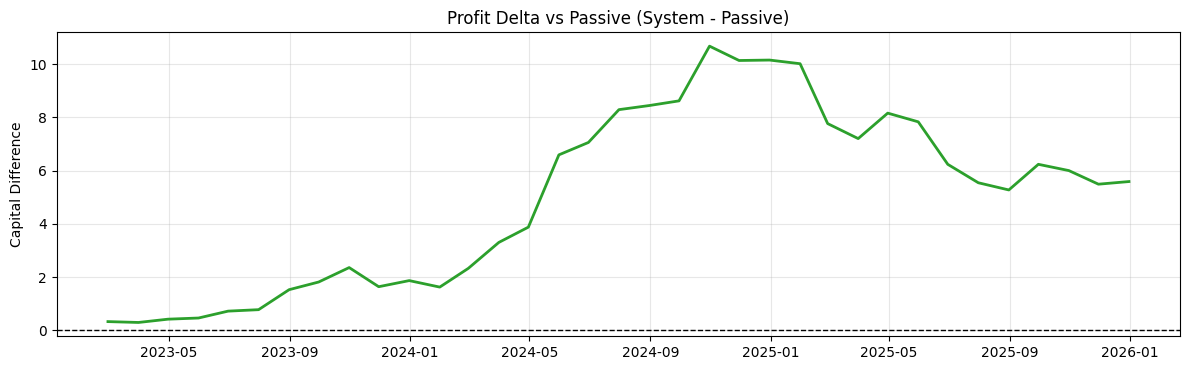

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df['capital_system_net'], label='System (Net)', linewidth=2)
ax.plot(df.index, df['capital_passive_net'], label='Passive Spread (Net)', linewidth=2)
ax.set_title('Cumulative Capital: System vs Passive')
ax.set_ylabel('Capital (start=100)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(df.index, df['profit_delta'], color='tab:green', linewidth=2)
ax.axhline(0.0, color='black', linewidth=1, linestyle='--')
ax.set_title('Profit Delta vs Passive (System - Passive)')
ax.set_ylabel('Capital Difference')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
def max_drawdown(capital: pd.Series) -> float:
    peak = capital.cummax()
    dd = capital / peak - 1.0
    return float(dd.min())

kpi = pd.DataFrame([
    {
        'metric': 'Final capital (system, net)',
        'value': round(float(df['capital_system_net'].iloc[-1]), 4),
    },
    {
        'metric': 'Final capital (passive, net)',
        'value': round(float(df['capital_passive_net'].iloc[-1]), 4),
    },
    {
        'metric': 'Profit delta (capital points)',
        'value': round(float(df['profit_delta'].iloc[-1]), 4),
    },
    {
        'metric': 'Total return system (%)',
        'value': round((float(df['capital_system_net'].iloc[-1]) / 100.0 - 1.0) * 100.0, 4),
    },
    {
        'metric': 'Total return passive (%)',
        'value': round((float(df['capital_passive_net'].iloc[-1]) / 100.0 - 1.0) * 100.0, 4),
    },
    {
        'metric': 'Max drawdown system (%)',
        'value': round(max_drawdown(df['capital_system_net']) * 100.0, 4),
    },
    {
        'metric': 'Months traded',
        'value': int(df['trade_enabled'].sum()),
    },
    {
        'metric': 'Trade hit rate (when traded)',
        'value': round(float((df.loc[df['trade_enabled'] == 1, 'strategy_net_ret'] > 0).mean()), 4) if int(df['trade_enabled'].sum()) > 0 else np.nan,
    },
])

display(Markdown('## Practical KPI Snapshot'))
display(kpi)

## Practical KPI Snapshot

,metric,value
0,"Final capital (system, net)",100.6938
1,"Final capital (passive, net)",95.1075
2,Profit delta (capital points),5.5863
3,Total return system (%),0.6938
4,Total return passive (%),-4.8925
5,Max drawdown system (%),-3.5349
6,Months traded,7.0000
7,Trade hit rate (when traded),0.2857


## Caveat Box: Sample and Sensitivity Limits

- Capital-path differences are sample-dependent and can vary with threshold and transaction-cost assumptions.
- Positive net path in this period should be treated as conditional evidence, not a guarantee of future profitability.
- Use reliability, stability, and unified inference artifacts for final claim strength.

In [5]:
reason_counts = (
    df.loc[df['trade_enabled'] == 0, 'reason_code']
    .value_counts(dropna=False)
    .rename_axis('reason_code')
    .reset_index(name='n_months')
)

display(Markdown('## Why Not Trade (No-Trade Reason Decomposition)'))
display(reason_counts)

display(Markdown('## Interpretation Guide'))
display(Markdown(
    '- If final system capital is above passive, the system added practical value in this sample.\n'
    '- If no-trade reasons dominate, the model is acting conservatively (confidence/edge filter).\n'
    '- Use this notebook together with `03`/`04` to explain *where* and *why* value appears.'
))

## Why Not Trade (No-Trade Reason Decomposition)

,reason_code,n_months
0,neutral_signal,17
1,signal_disagreement,6
2,insufficient_confidence,5


## Interpretation Guide

- If final system capital is above passive, the system added practical value in this sample.
- If no-trade reasons dominate, the model is acting conservatively (confidence/edge filter).
- Use this notebook together with `03`/`04` to explain *where* and *why* value appears.